In [24]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr

In [25]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../dataset/heart_clean.csv")

X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to numpy
X_train_np = x_train.to_numpy()
X_test_np = x_test.to_numpy()
y_train_np = y_train.to_numpy()

feature_names = X.columns

In [26]:

# =========================
# NOISE FUNCTION
# =========================
def inject_gaussian_noise(X, noise_level, random_state=42):
    rng = np.random.RandomState(random_state)
    noise = rng.normal(
        loc=0.0,
        scale=noise_level,
        size=X.shape
    )
    return X + noise



In [27]:
def compute_shap_importance_rf(model, X_test, feature_names):
    explainer = shap.TreeExplainer(model)
    
    shap_values = explainer.shap_values(X_test)
    
    # Binary classification → use class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    shap_values = np.array(shap_values)
    
    # Flatten only if necessary
    if shap_values.ndim == 3:
        # Sometimes shape is (n_samples, n_features, 1)
        shap_values = shap_values[:, :, 0]
    
    # Now compute mean absolute SHAP for each feature
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)  # shape = (n_features,)
    
    # Sanity check
    assert mean_abs_shap.shape[0] == len(feature_names), \
        f"Feature count mismatch: {mean_abs_shap.shape[0]} vs {len(feature_names)}"
    
    return pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)

In [28]:

# =========================
# BASELINE MODEL (NO NOISE)
# =========================
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train_np, y_train_np)

baseline_shap = compute_shap_importance_rf(
    baseline_model,
    X_test_np,
    feature_names
)

# Save baseline
baseline_shap.to_csv(
    "../results/rf_shap_baseline_feature_importance.csv",
    index=False
)

In [29]:
# =========================
# NOISE EXPERIMENT
# =========================
noise_levels = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80]

results = []

for noise in noise_levels:
    
    # Inject noise into training data
    X_train_noisy = inject_gaussian_noise(
        X_train_np,
        noise_level=noise,
        random_state=42
    )
    
    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_noisy, y_train_np)
    
    results.append({
        "noise_level": noise,
        "model": model
    })


# =========================
# SHAP COMPUTATION
# =========================
shap_results = {}

for r in results:
    noise = r["noise_level"]
    model = r["model"]
    
    shap_df = compute_shap_importance_rf(
        model,
        X_test_np,
        feature_names
    )
    
    shap_results[noise] = shap_df
    
    shap_df.to_csv(
        f"../results/rf_shap_noise_{noise}.csv",
        index=False
    )


In [30]:
# =========================
# STABILITY CALCULATION
# =========================
stability_results = []

for noise, shap_df in shap_results.items():
    
    merged = baseline_shap.merge(
        shap_df,
        on="feature",
        suffixes=("_baseline", "_noise")
    )
    
    rho, _ = spearmanr(
        merged["mean_abs_shap_baseline"],
        merged["mean_abs_shap_noise"]
    )
    
    stability_results.append({
        "noise_level": noise,
        "spearman_rank_correlation": rho
    })

stability_df = pd.DataFrame(stability_results)

# Save results
stability_df.to_csv(
    "../results/rf_interpretability_stability.csv",
    index=False
)

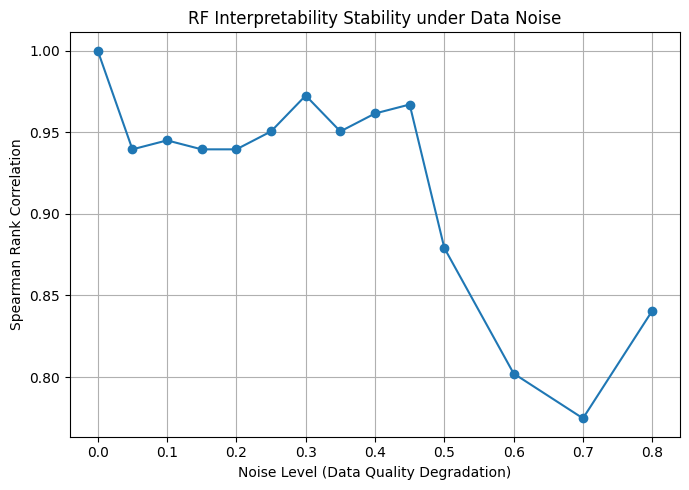

In [31]:
# =========================
# PLOT
# =========================
plt.figure(figsize=(7, 5))

plt.plot(
    stability_df["noise_level"],
    stability_df["spearman_rank_correlation"],
    marker="o"
)

plt.xlabel("Noise Level (Data Quality Degradation)")
plt.ylabel("Spearman Rank Correlation")
plt.title("RF Interpretability Stability under Data Noise")

plt.grid(True)
plt.tight_layout()
plt.show()